# QU QML Power Spectrum Analysis

This notebook provides a step-by-step analysis of QML power spectrum estimation for QU (E-B mode) polarization data.

## 1. Import Required Libraries

In [17]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from mpi4py import MPI

# Import cosmocore modules
from cosmocore import (
    InputParams,
    do_derivative_step,
    matrix_mult,
    matrix_trace,
)

# Import quelo modules
from quelo import Spectra


# Set up plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)

print("All imports successful!")
print(f"MPI size: {MPI.COMM_WORLD.Get_size()}, rank: {MPI.COMM_WORLD.Get_rank()}")

All imports successful!
MPI size: 1, rank: 0


In [18]:
def configure_plt():
    plt.rc("axes", labelsize=20, linewidth=1.5)
    plt.rc("xtick", direction="in", labelsize=15, top=True)
    plt.rc("ytick", direction="in", labelsize=15, right=True)

    plt.rc("xtick.major", width=1.1, size=5)
    plt.rc("ytick.major", width=1.1, size=5)

    plt.rc("xtick.minor", width=1.1, size=3)
    plt.rc("ytick.minor", width=1.1, size=3)

    plt.rc("lines", linewidth=2)
    plt.rc("legend", frameon=False, fontsize=15)
    plt.rc("figure", dpi=100, autolayout=True, figsize=[10, 7])
    plt.rc("savefig", dpi=300, bbox="tight")


configure_plt()

## 2. Setup Test Parameters and Configuration

In [19]:
# Set up test configuration paths
local_path = os.path.abspath(os.getcwd())
fields = "QU"  # Use TQU configuration for debugging
nside = 4
param_file = f"{local_path}/../tests/data/nside{nside}/{fields}/config.yaml"

print(f"Local path: {local_path}")
print(f"Parameter file: {param_file}")
print(f"Parameter file exists: {os.path.exists(param_file)}")

# Load parameters
params = InputParams.read_parameter_file(param_file)

# Display key parameters
print("\n=== Key Parameters ===")
print(f"nside: {params.nside}")
print(f"spins: {params.spins}")
print(f"labels: {getattr(params, 'labels', 'Not specified')}")
print(f"nspectra: {params.nspectra}")
print(f"lmax: {params.lmax}")
print(f"nsims: {params.nsims}")
print(f"do_cross: {params.do_cross}")
print(f"calibration: {params.calibration}")

Local path: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/notebooks
Parameter file: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/notebooks/../tests/data/nside4/QU/config.yaml
Parameter file exists: True

=== Key Parameters ===
nside: 4
spins: [2]
labels: ['E', 'B']
nspectra: 3
lmax: 16
nsims: 300
do_cross: False
calibration: 1.0


## 3. Initialize Spectra Instance

In [20]:
# Initialize Spectra instance
print("Creating Spectra instance...")
spectra = Spectra(param_file)

# Display MPI and basic info
print(f"MPI rank: {spectra.rank}")
print(f"MPI size: {spectra.size}")
print(f"Parameters loaded: {spectra.params is not None}")
print(f"Fisher instance created: {spectra.fisher_instance is not None}")

# Display initial variable states
print("\n=== Initial Variable States ===")
print(f"maps1: {spectra.maps1}")
print(f"maps2: {spectra.maps2}")
print(f"y: {spectra.y}")
print(f"ynb: {spectra.ynb}")
print(f"invfisher: {spectra.invfisher}")

Creating Spectra instance...
Starting Fisher matrix computation...
Starting Fisher matrix analysis pipeline
--------------------------------------------------------------------------------
Fisher matrix computation completed
Fisher matrix computation completed in 5.25 seconds
MPI rank: 0
MPI size: 1
Parameters loaded: True
Fisher instance created: True

=== Initial Variable States ===
maps1: None
maps2: None
y: None
ynb: None
invfisher: None


## 4. Setup Fields and Geometry

In [21]:
# Execute setup_fields() and setup_geometry()
print("=== Setting up fields ===")
spectra.setup_fields()
print("Fields setup completed")

print("\n=== Setting up geometry ===")
spectra.setup_geometry()
print("Geometry setup completed")

# Inspect results
print("\n=== Geometry Results ===")
print(f"npixs type: {type(spectra.npixs)}")
print(f"npixs: {spectra.npixs}")
print(f"n_active: {spectra.collection.n_active}")
print(f"Total pixels: {sum(spectra.collection.n_active)}")

if hasattr(spectra, "pixact") and spectra.pixact is not None:
    print(f"pixact type: {type(spectra.pixact)}")
    print(f"pixact length: {len(spectra.pixact)}")
    for i, pix in enumerate(spectra.pixact):
        print(
            f"  Field {i}: {len(pix) if hasattr(pix, '__len__') else pix} active pixels"
        )

# Check collection and spectra labels
if hasattr(spectra, "collection") and spectra.collection is not None:
    print(f"\nSpectra labels: {spectra.collection.spectra_labels}")
    print(f"Number of spectra: {len(spectra.collection.spectra_labels)}")

    # This is the KEY issue we're investigating
    print("Expected spectra: ['EE', 'BB', 'EB']")
    print(f"Actual spectra: {spectra.collection.spectra_labels}")
else:
    print("Collection not available")

=== Setting up fields ===
Fields setup completed

=== Setting up geometry ===
Geometry setup completed

=== Geometry Results ===
npixs type: <class 'list'>
npixs: [192]
n_active: [192, 192]
Total pixels: 384
pixact type: <class 'numpy.ndarray'>
pixact length: 2
  Field 0: 192 active pixels
  Field 1: 192 active pixels

Spectra labels: ['EE', 'BB', 'EB']
Number of spectra: 3
Expected spectra: ['EE', 'BB', 'EB']
Actual spectra: ['EE', 'BB', 'EB']


## 5. Load Maps Data

In [22]:
# Execute setup_maps() - this follows the exact pattern from spectra.run()
print("=== Loading maps ===")
# Read maps using the core functionality
ntot = sum(spectra.collection.n_active)
print(f"Total active pixels (ntot): {ntot}")
spectra.maps1 = np.empty((ntot, spectra.params.nsims), dtype=np.float64)

# Load from multi-extension FITS file
filename = f"{spectra.params.inputmapfile1.rsplit('_', 1)[0]}/maps/all_sims_TQU.fits"
filename = (
    f"{spectra.params.inputmapfile1.rsplit('sim', 1)[0]}"
    f"all_sims{spectra.params.endname1}.fits"
)
print(f"Loading from multi-extension FITS: {filename}")

with fits.open(filename) as hdul:
    print(f"Number of extensions: {len(hdul)}")
    for isim in range(spectra.params.nsims):
        ext_name = f"SIM_{isim:03d}"
        if ext_name in hdul:
            sim_data = hdul[ext_name].data
            sim = sim_data[1:]
            spectra.maps1[:, isim] = np.concatenate(sim)
        else:
            print(f"Warning: Extension {ext_name} not found")

# Apply calibration
spectra.maps1 *= spectra.params.calibration
print("Maps loaded")

print("\n=== Maps1 Info ===")
print(f"maps1 shape: {spectra.maps1.shape}")
print(f"maps1 dtype: {spectra.maps1.dtype}")
print(f"maps1 min/max: {spectra.maps1.min():.3e} / {spectra.maps1.max():.3e}")
print(f"maps1 mean/std: {spectra.maps1.mean():.3e} / {spectra.maps1.std():.3e}")

=== Loading maps ===
Total active pixels (ntot): 384
Loading from multi-extension FITS: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/tests/data/nside4/maps/all_sims_TQU.fits
Number of extensions: 301
Maps loaded

=== Maps1 Info ===
maps1 shape: (384, 300)
maps1 dtype: float64
maps1 min/max: -7.082e-01 / 6.219e-01
maps1 mean/std: -7.779e-04 / 1.551e-01


## 6. Load Covariance Matrices

In [23]:
# Load covariance matrices - from spectra.run()
print("=== Loading covariance matrices ===")

ntot = sum(spectra.collection.n_active)
print(f"Total matrix size: {ntot} x {ntot}")

# Load invCov1 (inverted covariance matrix)
print(f"Loading invCov1 from: {spectra.params.outinvcovmatfile1}")
spectra.invCov1 = np.fromfile(spectra.params.outinvcovmatfile1).reshape((ntot, ntot))

# Load NCov1 (noise covariance matrix)
print(f"Loading NCov1 from: {spectra.params.covmatfile1}")
spectra.NCov1 = np.fromfile(spectra.params.covmatfile1).reshape((ntot, ntot))

# Inspect covariance matrices
print("\n=== Covariance Matrix Info ===")
print(f"invCov1 shape: {spectra.invCov1.shape}")
print(f"invCov1 dtype: {spectra.invCov1.dtype}")

print(f"\nNCov1 shape: {spectra.NCov1.shape}")
print(f"NCov1 dtype: {spectra.NCov1.dtype}")

=== Loading covariance matrices ===
Total matrix size: 384 x 384
Loading invCov1 from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/tests/data/nside4/QU/invCOV1.bin
Loading NCov1 from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/tests/data/nside4/QU/NCVM1.bin

=== Covariance Matrix Info ===
invCov1 shape: (384, 384)
invCov1 dtype: float64

NCov1 shape: (384, 384)
NCov1 dtype: float64


## 7. Setup Cls and Beams

In [24]:
# Setup Cls and beams - from spectra.run()
print("=== Setting up Cls ===")
spectra.setup_cls()
print("Cls setup completed")

print("\n=== Setting up beams ===")
spectra.setup_beams()
print("Beams setup completed")

# Inspect the spectra collection
print("\n=== Spectra Collection Info ===")
if hasattr(spectra, "collection") and spectra.collection is not None:
    print(f"Collection type: {type(spectra.collection)}")

    # Get spectra manager info
    if hasattr(spectra.collection, "spectra_manager"):
        mgr = spectra.collection.spectra_manager
        print(f"Spectra labels: {mgr.labels}")
        print(f"Number of spectra: {mgr.n_spectra}")

        # Show reference Cls values
        print("\n=== Reference Cls Values (first few ell) ===")
        if hasattr(mgr, "_cls_dict"):
            for label in mgr.labels:
                if label in mgr._cls_dict:
                    cls_vals = mgr._cls_dict[label]
                    print(f"{label}: {cls_vals[:5]} (ell=2-6)")

    # Get beam manager info
    if hasattr(spectra.collection, "beam_manager"):
        print(f"\nBeam manager available: {spectra.collection.beam_manager is not None}")
else:
    print("Collection not available")

=== Setting up Cls ===
Cls setup completed

=== Setting up beams ===
Beams setup completed

=== Spectra Collection Info ===
Collection type: <class 'cosmocore.fields.FieldCollection'>
Spectra labels: ['EE', 'BB', 'EB']
Number of spectra: 3

=== Reference Cls Values (first few ell) ===
EE: [5.97485544e-04 1.11657403e-04 2.58566625e-05 6.24210286e-06
 1.49889151e-06] (ell=2-6)
BB: [2.94356507e-08 8.08066698e-09 3.37305859e-09 1.70957500e-09
 9.71038631e-10] (ell=2-6)
EB: [0. 0. 0. 0. 0.] (ell=2-6)

Beam manager available: True


## 8. Compute Smoothing Factors and vecmul

In [25]:
# Compute smoothing factors - from spectra.run()
print("=== Computing smoothing factors ===")

smoothing_factors = spectra.collection.spectra_manager.compute_smoothing_factors(
    spectra.collection.beam_manager
)

print(f"Smoothing factors computed for: {list(smoothing_factors.keys())}")

# Create vecmul array
nell = spectra.params.nspectra * (spectra.params.lmax - 1)
vecmul = np.zeros(nell, dtype=np.float64)

print(
    f"\nvecmul array size: {nell} "
    f"(nspectra={spectra.params.nspectra}, lmax-1={spectra.params.lmax - 1})"
)

# Fill vecmul array
idx = 0
for ispec, spectrum_label in enumerate(spectra.collection.spectra_manager.labels):
    print(f"\nProcessing spectrum {ispec}: {spectrum_label}")

    if spectrum_label in smoothing_factors:
        smooth_factor = smoothing_factors[spectrum_label]
        print(f"  Smoothing factors (first 5): {smooth_factor[:5]}")

        for ell_idx in range(spectra.params.lmax - 1):
            vecmul[idx] = smooth_factor[ell_idx]
            idx += 1

        print(f"  Added {spectra.params.lmax - 1} factors to vecmul")
    else:
        print(f"  ⚠️  No smoothing factors found for {spectrum_label}")

spectra.vecmul = vecmul

print("\n=== vecmul Summary ===")
print(f"vecmul shape: {spectra.vecmul.shape}")
print(f"vecmul min/max: {spectra.vecmul.min():.3e} / {spectra.vecmul.max():.3e}")
print(f"vecmul first 10 values: {spectra.vecmul[:10]}")

=== Computing smoothing factors ===
Smoothing factors computed for: ['EE', 'BB', 'EB']

vecmul array size: 45 (nspectra=3, lmax-1=15)

Processing spectrum 0: EE
  Smoothing factors (first 5): [1.04027175 0.50988365 0.29791641 0.19212896 0.13187781]
  Added 15 factors to vecmul

Processing spectrum 1: BB
  Smoothing factors (first 5): [1.04027175 0.50988365 0.29791641 0.19212896 0.13187781]
  Added 15 factors to vecmul

Processing spectrum 2: EB
  Smoothing factors (first 5): [1.04027175 0.50988365 0.29791641 0.19212896 0.13187781]
  Added 15 factors to vecmul

=== vecmul Summary ===
vecmul shape: (45,)
vecmul min/max: 9.490e-03 / 1.040e+00
vecmul first 10 values: [1.04027175 0.50988365 0.29791641 0.19212896 0.13187781 0.09441845
 0.06963904 0.05248064 0.040181   0.03112621]


## 9. Load and Process Fisher Matrix

In [26]:
# Load and process Fisher matrix - from spectra.run()
print("=== Loading Fisher matrix ===")

# Load Fisher matrix
print(f"Loading Fisher from: {spectra.params.outfilefisher}")
spectra.invfisher = np.loadtxt(spectra.params.outfilefisher)

print(f"Fisher shape: {spectra.invfisher.shape}")
print(f"Fisher diagonal (first 5): {np.diag(spectra.invfisher)[:5]}")

# Apply vecmul normalization (CRITICAL STEP)
print("\n=== Applying vecmul normalization ===")
nell = len(spectra.vecmul)
print(f"Applying normalization to {nell} x {nell} matrix")

print("Before normalization:")
print(f"  Fisher[0,0]: {spectra.invfisher[0, 0]:.3e}")
print(f"  vecmul[0]: {spectra.vecmul[0]:.3e}")

# This is the key operation that might cause scaling issues
spectra.invfisher = spectra.invfisher * np.outer(spectra.vecmul, spectra.vecmul)

# Invert the normalized Fisher matrix
print("\n=== Inverting Fisher matrix ===")
spectra.invfisher = np.linalg.inv(spectra.invfisher)

=== Loading Fisher matrix ===
Loading Fisher from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/tests/data/nside4/QU/fisher.dat
Fisher shape: (45, 45)
Fisher diagonal (first 5): [   1923.8678    6044.9995   26603.735   152840.85   1088854.9   ]

=== Applying vecmul normalization ===
Applying normalization to 45 x 45 matrix
Before normalization:
  Fisher[0,0]: 1.924e+03
  vecmul[0]: 1.040e+00

=== Inverting Fisher matrix ===


## 10. Initialize QML Variables

In [27]:
# Initialize QML variables - from spectra.run()
print("=== Initializing QML variables ===")

nell = spectra.params.nspectra * (spectra.params.lmax - 1)

# Initialize y vectors for QML estimation
spectra.y = np.zeros((spectra.params.nsims, nell), dtype=np.float64)
print(f"Initialized y array: shape={spectra.y.shape}, dtype={spectra.y.dtype}")

# Initialize noise bias only for auto-correlation case
if not spectra.params.do_cross:
    spectra.ynb = np.zeros(nell, dtype=np.float64)
    print(f"Initialized ynb array: shape={spectra.ynb.shape}, dtype={spectra.ynb.dtype}")
else:
    print("Cross-correlation mode: no noise bias computation")

# Prepare for main computation loop
ntot = sum(spectra.collection.n_active)
print("\n=== Computation Setup ===")
print(f"Total matrix size: {ntot}")
print(f"Number of multipole bins: {nell}")
print(f"Number of simulations: {spectra.params.nsims}")
print(f"MPI size: {spectra.size}")

# Allocate working arrays
der_s = np.zeros((ntot, ntot), dtype=np.float64)
E = np.zeros((ntot, ntot), dtype=np.float64)
print(f"Allocated working matrices: {der_s.shape}, {E.shape}")

print("\n✅ All variables initialized and ready for computation")

=== Initializing QML variables ===
Initialized y array: shape=(300, 45), dtype=float64
Initialized ynb array: shape=(45,), dtype=float64

=== Computation Setup ===
Total matrix size: 384
Number of multipole bins: 45
Number of simulations: 300
MPI size: 1
Allocated working matrices: (384, 384), (384, 384)

✅ All variables initialized and ready for computation


## 11. Main QML Computation Loop

In [28]:
# Main QML computation loop - from spectra.run()
print("=== Starting main QML computation ===")

nell = spectra.params.nspectra * (spectra.params.lmax - 1)
ntot = sum(spectra.collection.n_active)

# Allocate derivative matrix
der_s = np.zeros((ntot, ntot), dtype=np.float64)
E = np.zeros((ntot, ntot), dtype=np.float64)

start_time = time.time()

# Main computation loop - simplified for single process debugging
print(f"Processing {nell} multipole bins...")

# Track computation for debugging
computation_info = []

for il in range(nell):
    # Skip MPI distribution for debugging - process all
    print(f"\n--- Processing bin {il} ---")

    # Compute derivative of signal matrix for this multipole
    spectrum_idx = il // (spectra.params.lmax - 1)
    ell = (il % (spectra.params.lmax - 1)) + 2

    spec_label = spectra.collection.spectra_labels[spectrum_idx]

    print(f"  Spectrum {spectrum_idx}: {spec_label}, ell={ell}")

    # This is where the derivative computation happens
    do_derivative_step(
        der_s,
        spectrum_idx,
        spectra.npixs,
        spectra.params.spins,
        ell,
        spectra.collection,
    )

    # Compute E matrix
    E = 0.5 * matrix_mult(spectra.invCov1, matrix_mult(der_s, spectra.invCov1))

    # Compute noise bias
    tr_ne = matrix_trace(spectra.NCov1, E)
    spectra.ynb[il] = tr_ne

    # Compute signal for each simulation
    for field_idx in range(spectra.params.nsims):
        spectra.y[field_idx, il] = matrix_mult(
            spectra.maps1[:, field_idx].T, matrix_mult(E, spectra.maps1[:, field_idx])
        )

    # Subtract noise bias
    for field_idx in range(spectra.params.nsims):
        spectra.y[field_idx, il] = spectra.y[field_idx, il] - spectra.ynb[il]

    # Store info for analysis
    info = {
        "il": il,
        "spectrum": spec_label,
        "ell": ell,
        "noise_bias": spectra.ynb[il],
        "signal_sim0": spectra.y[0, il],
        "der_s_trace": np.trace(der_s),
        "E_trace": np.trace(E),
    }
    computation_info.append(info)

    print(f"  Noise bias: {spectra.ynb[il]:.3e}")
    print(f"  Signal (sim 0): {spectra.y[0, il]:.3e}")
    print(f"  der_s trace: {np.trace(der_s):.3e}")
    print(f"  E trace: {np.trace(E):.3e}")

elapsed = time.time() - start_time
print(f"\nComputation completed in {elapsed:.2f} seconds")

=== Starting main QML computation ===
Processing 45 multipole bins...

--- Processing bin 0 ---
  Spectrum 0: EE, ell=2
  Noise bias: 1.640e-02
  Signal (sim 0): 3.361e+01
  der_s trace: 7.639e+01
  E trace: 1.269e+02

--- Processing bin 1 ---
  Spectrum 0: EE, ell=3


  Noise bias: 5.148e-02
  Signal (sim 0): 2.263e+02
  der_s trace: 1.070e+02
  E trace: 3.982e+02

--- Processing bin 2 ---
  Spectrum 0: EE, ell=4
  Noise bias: 2.283e-01
  Signal (sim 0): 3.223e+02
  der_s trace: 1.375e+02
  E trace: 1.766e+03

--- Processing bin 3 ---
  Spectrum 0: EE, ell=5
  Noise bias: 1.311e+00
  Signal (sim 0): 5.658e+02
  der_s trace: 1.681e+02
  E trace: 1.014e+04

--- Processing bin 4 ---
  Spectrum 0: EE, ell=6
  Noise bias: 9.489e+00
  Signal (sim 0): 2.611e+03
  der_s trace: 1.986e+02
  E trace: 7.340e+04

--- Processing bin 5 ---
  Spectrum 0: EE, ell=7
  Noise bias: 7.170e+01
  Signal (sim 0): 1.213e+04
  der_s trace: 2.292e+02
  E trace: 5.546e+05

--- Processing bin 6 ---
  Spectrum 0: EE, ell=8
  Noise bias: 4.448e+02
  Signal (sim 0): 1.374e+04
  der_s trace: 2.597e+02
  E trace: 3.440e+06

--- Processing bin 7 ---
  Spectrum 0: EE, ell=9
  Noise bias: 1.439e+03
  Signal (sim 0): 3.529e+04
  der_s trace: 2.903e+02
  E trace: 1.113e+07

--- Processin

## 12. Final Matrix Multiplication

In [29]:
# Apply final Fisher matrix multiplication - from spectra.run()
print("=== Applying final Fisher matrix multiplication ===")

print("Before final multiplication:")
print(f"y[0] first 5 values: {spectra.y[0, :5]}")
print(f"vecmul first 5 values: {spectra.vecmul[:5]}")
print(f"invfisher[0,0]: {spectra.invfisher[0, 0]:.3e}")

power_spectra = np.zeros_like(spectra.y)
for field_idx in range(spectra.params.nsims):
    # Element-wise multiplication first, then matrix multiplication
    redy_times_vecmul = spectra.y[field_idx, :] * spectra.vecmul
    power_spectra[field_idx, :] = np.matmul(redy_times_vecmul, spectra.invfisher)

print(f"first 5 values: {power_spectra[0, :5]}")

print("\n✅ Final multiplication completed")

=== Applying final Fisher matrix multiplication ===
Before final multiplication:
y[0] first 5 values: [  33.60990885  226.33225445  322.34586776  565.7549218  2610.61524548]
vecmul first 5 values: [1.04027175 0.50988365 0.29791641 0.19212896 0.13187781]
invfisher[0,0]: 4.803e-04
first 5 values: [0.01679358 0.0734308  0.0406706  0.01926538 0.01817845]

✅ Final multiplication completed


## 13. Validate Results and Output

=== Validation and Visualization ===
=== Plotting Original Fiducial Spectra ===


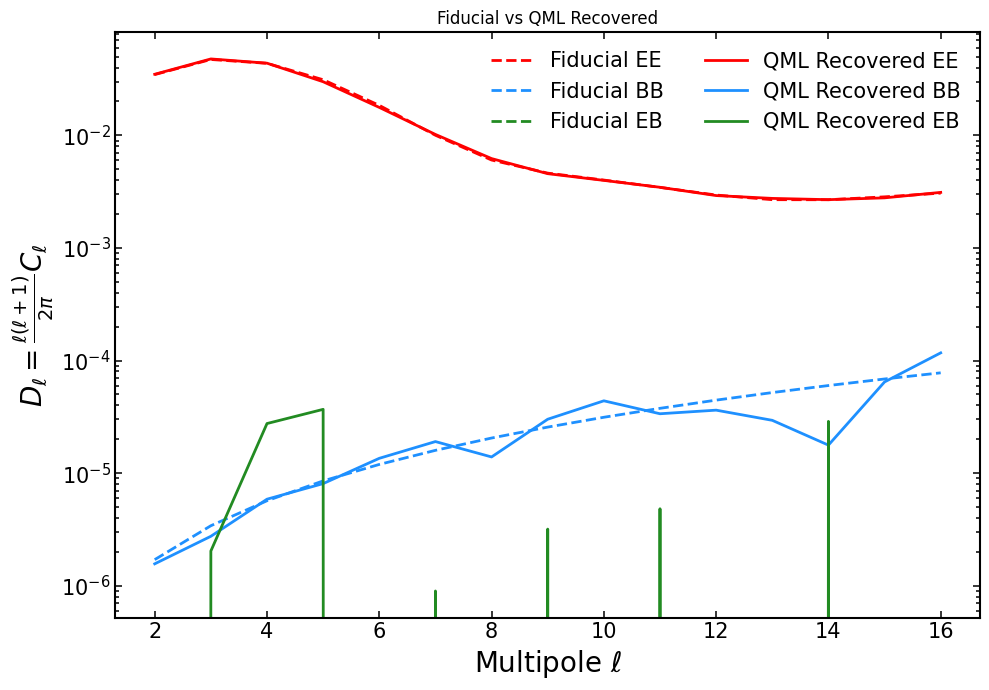

In [30]:
# Validate results and create diagnostic plots
print("=== Validation and Visualization ===")

# Create diagnostic plots
fig, ax = plt.subplots()

# Define colors and labels
colors = ["red", "dodgerblue", "forestgreen", "orange", "purple", "maroon"]
labels = ["TT", "EE", "BB", "TE", "TB", "EB"]

ell = np.arange(2, spectra.params.lmax + 1)
n_ell = len(ell)

# Plot original fiducial spectra (before normalizations and smoothing)
print("=== Plotting Original Fiducial Spectra ===")

# Load the original input spectra from the file used to generate simulations
original_clfid = np.loadtxt(params.inputclfile)
ell = original_clfid[:, 0].astype(int)

# Map original spectrum columns to labels
spectrum_map = {
    "TT": 1,  # Column 1 in original file
    "EE": 2,  # Column 2
    "BB": 3,  # Column 3
    "TE": 4,  # Column 4
    "TB": 5,  # Column 5 (should be zero)
    "EB": 6,  # Column 6 (should be zero)
}

# Plot original fiducial spectra
for ispec, spec_label in enumerate(["EE", "BB", "EB"]):  # All TEB spectra
    if spec_label in spectrum_map and spectrum_map[spec_label] < original_clfid.shape[1]:
        col_idx = spectrum_map[spec_label]
        # Extract the relevant ell range
        ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
        original_spectrum = original_clfid[ell_mask, col_idx]
        ell_plot = ell[ell_mask]

        ax.plot(
            ell_plot,
            original_spectrum,
            "--",
            color=colors[ispec],
            linewidth=2,
            label=f"Fiducial {spec_label}",
            alpha=1,
        )

# Plot computed spectra for comparison
for ispec, spec_label in enumerate(spectra.collection.spectra_labels):
    start_idx = ispec * n_ell
    end_idx = (ispec + 1) * n_ell

    # Plot computed spectrum (average over simulations)
    computed = power_spectra[:, start_idx:end_idx].mean(axis=0)

    ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
    ell_plot = ell[ell_mask]

    ax.plot(
        ell_plot,
        computed,
        color=colors[ispec],
        label=f"QML Recovered {spec_label}",
        alpha=1,
    )

ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell = \frac{{\ell(\ell+1)}}{{2π}}C_\ell$")
ax.set_title("Fiducial vs QML Recovered")
ax.legend(ncol=2)
ax.set_yscale("log")
plt.show()

In [31]:
# Print comparison statistics
print("\n=== Spectrum Comparison Summary ===")
for ispec, spec_label in enumerate(spectra.collection.spectra_labels):
    start_idx = ispec * n_ell
    end_idx = (ispec + 1) * n_ell
    computed = power_spectra[:, start_idx:end_idx].mean(axis=0)

    if spec_label in spectrum_map and spectrum_map[spec_label] < original_clfid.shape[1]:
        col_idx = spectrum_map[spec_label]
        ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
        original_spectrum = original_clfid[ell_mask, col_idx]

        if spec_label == "EB":
            print(f"{spec_label}: Original spectrum is zero!")
            mean = np.mean(computed)
            std = np.std(computed)

            print(f"{spec_label}: QML mean = {mean:.3f} ± {std:.3f}")
            continue

        ratio_mean = np.mean(computed / original_spectrum)
        ratio_std = np.std(computed / original_spectrum)

        print(f"{spec_label}: QML/Original ratio = {ratio_mean:.3f} ± {ratio_std:.3f}")
        if ratio_mean > 10 or ratio_mean < 0.1:
            print(f"  ⚠️  Large scaling difference in {spec_label}!")


=== Spectrum Comparison Summary ===
EE: QML/Original ratio = 0.999 ± 0.020
BB: QML/Original ratio = 0.954 ± 0.300
EB: Original spectrum is zero!
EB: QML mean = -0.000 ± 0.000
